In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
import numpy as np
from sklearn.metrics import mean_squared_error

In [2]:
crime = pd.read_csv("crime-housing-austin-2015.csv")

# Figure out best geographical unit to divide statistics

In [3]:
crime.groupby('Zip_Code_Crime').Medianhomevalue.unique()
crime.groupby('Zip_Code_Crime').Unemployment.unique()
crime.groupby('Zip_Code_Crime').Rentalunitsaffordabletoaverageartist.unique()

Zip_Code_Crime
78613.0    [nan]
78617.0    [24%]
78652.0    [nan]
78653.0    [nan]
78660.0    [nan]
78701.0    [12%]
78702.0    [51%]
78703.0    [25%]
78704.0    [26%]
78705.0    [23%]
78712.0    [nan]
78717.0     [9%]
78719.0    [nan]
78721.0    [39%]
78722.0    [31%]
78723.0    [44%]
78724.0    [22%]
78725.0    [nan]
78726.0     [8%]
78727.0    [11%]
78728.0    [24%]
78729.0    [17%]
78730.0     [3%]
78731.0    [24%]
78732.0     [0%]
78733.0    [nan]
78735.0     [7%]
78736.0    [nan]
78737.0    [nan]
78739.0     [0%]
78741.0    [40%]
78742.0    [76%]
78744.0    [22%]
78745.0    [24%]
78746.0     [8%]
78747.0    [nan]
78748.0    [12%]
78749.0     [6%]
78750.0    [15%]
78751.0    [38%]
78752.0    [55%]
78753.0    [40%]
78754.0    [22%]
78756.0    [34%]
78757.0    [32%]
78758.0    [32%]
78759.0    [18%]
Name: Rentalunitsaffordabletoaverageartist, dtype: object

In [4]:
crime.groupby('Census_Tract').Medianhomevalue.unique()
crime.groupby('Census_Tract').Unemployment.unique()
crime.groupby('Census_Tract').Rentalunitsaffordabletoaverageartist.unique()

Census_Tract
1.01            [24%]
1.02            [24%]
2.03       [38%, 34%]
2.04       [23%, 34%]
2.05            [34%]
              ...    
204.11          [17%]
205.08           [9%]
205.09           [9%]
205.10           [9%]
9800.00    [nan, 24%]
Name: Rentalunitsaffordabletoaverageartist, Length: 205, dtype: object

In [5]:
crime.groupby('Council_District').Medianhomevalue.unique()
crime.groupby('Council_District').Unemployment.unique()
crime.groupby('Council_District').Rentalunitsaffordabletoaverageartist.unique()

Council_District
1.0     [40%, 39%, 51%, nan, 44%, 22%, 12%, 31%, 55%, ...
2.0                             [22%, nan, 24%, 12%, 76%]
3.0         [40%, 26%, 51%, 24%, 39%, 76%, nan, 22%, 12%]
4.0                             [40%, 38%, 55%, 32%, 44%]
5.0                     [24%, 12%, nan, 26%, 22%, 7%, 6%]
6.0             [17%, 8%, 9%, 15%, nan, 11%, 18%, 0%, 3%]
7.0         [11%, 18%, 32%, 40%, 34%, nan, 22%, 24%, 55%]
8.0                       [8%, 6%, 7%, 0%, nan, 12%, 24%]
9.0     [40%, 12%, 44%, 26%, 31%, 38%, 25%, 23%, 34%, ...
10.0    [18%, 24%, 25%, 3%, 8%, 23%, 32%, 34%, 15%, na...
Name: Rentalunitsaffordabletoaverageartist, dtype: object

In [6]:
crime.groupby('District').Medianhomevalue.unique()
crime.groupby('District').Unemployment.unique()
crime.groupby('District').Rentalunitsaffordabletoaverageartist.unique()

District
A     [11%, 18%, 32%, 17%, 8%, 9%, 15%, nan, 3%, 0%,...
AP                                           [nan, 27%]
B     [32%, 44%, 12%, 34%, 24%, 25%, 18%, 38%, 23%, ...
C          [39%, 51%, nan, 44%, 31%, 22%, 6%, 27%, 12%]
D     [26%, 24%, 8%, 6%, 7%, 0%, nan, 32%, 12%, 27%,...
E         [40%, 32%, nan, 22%, 24%, 11%, 27%, 44%, 39%]
F                     [22%, 12%, 24%, nan, 6%, 27%, 0%]
G                                  [51%, 12%, 25%, 27%]
H     [40%, 24%, 22%, 26%, 76%, nan, 27%, 12%, 55%, ...
I     [38%, 40%, 55%, 44%, 32%, 34%, 22%, 12%, 24%, ...
UK                                                [27%]
Name: Rentalunitsaffordabletoaverageartist, dtype: object

Figured out that the statistics are calculated using Zip Code

# Violent vs Nonviolent Crime

In [7]:
crime.Highest_Offense_Desc.unique()

<StringArray>
[     'AGG ROBBERY/DEADLY WEAPON',             'ROBBERY BY ASSAULT',
          'BURGLARY OF RESIDENCE',         'BURGLARY NON RESIDENCE',
                     'AUTO THEFT', 'AGG ASLT W/MOTOR VEH FAM/DAT V',
    'AGG ASLT STRANGLE/SUFFOCATE',                    'AGG ASSAULT',
 'AGG ASLT ENHANC STRANGL/SUFFOC',              'THEFT FROM PERSON',
           'THEFT BY SHOPLIFTING',            'BURGLARY OF VEHICLE',
                           'RAPE',         'THEFT OF LICENSE PLATE',
            'THEFT OF AUTO PARTS',                          'THEFT',
    'BREACH OF COMPUTER SECURITY',       'BURG NON RESIDENCE SHEDS',
                 'DEADLY CONDUCT',  'AGG ASSAULT FAM/DATE VIOLENCE',
            'THEFT FROM BUILDING',                'THEFT FROM AUTO',
         'THEFT OF VEHICLE/OTHER',       'THEFT OF HEAVY EQUIPMENT',
            'AGG RAPE OF A CHILD',                       'AGG RAPE',
                 'THEFT OF METAL',               'THEFT OF BICYCLE',
    'BURGLARY OF COI

C:\Users\csaxt\AppData\Local\Temp\ipykernel_48980\3035096729.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Violent Crimes", "Nonviolent Crimes"])


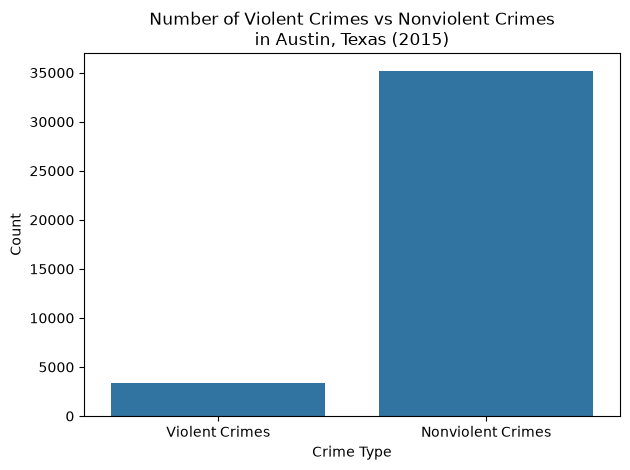

In [8]:
crime['violent_crime'] = crime.Highest_Offense_Desc.isin(['AGG ROBBERY/DEADLY WEAPON','ROBBERY BY ASSAULT','AGG ASLT W/MOTOR VEH FAM/DAT V',
    'AGG ASLT STRANGLE/SUFFOCATE','AGG ASSAULT','AGG ASLT ENHANC STRANGL/SUFFOC','RAPE','DEADLY CONDUCT','AGG ASSAULT FAM/DATE VIOLENCE',
    'AGG RAPE OF A CHILD','AGG RAPE','ROBBERY BY THREAT','AGG ROBBERY BY ASSAULT','RAPE OF A CHILD','AGG ASSAULT WITH MOTOR VEH','MURDER',
    'AGG ASSAULT ON PUBLIC SERVANT','BURG OF RES - SEXUAL NATURE', 'DEADLY CONDUCT FAM/DATE VIOL','TAKE WEAPON FRM POLICE OFFICER',
    'MANSLAUGHTER'])

crime['violent_crime_string'] = crime['violent_crime'].astype('string')

ax = sns.countplot(x="violent_crime_string", data=crime)
ax.set_xticklabels(["Violent Crimes", "Nonviolent Crimes"])
ax.set_ylabel("Count")
ax.set_title("Number of Violent Crimes vs Nonviolent Crimes\nin Austin, Texas (2015)")
ax.set_xlabel("Crime Type")

plt.tight_layout()
plt.show()

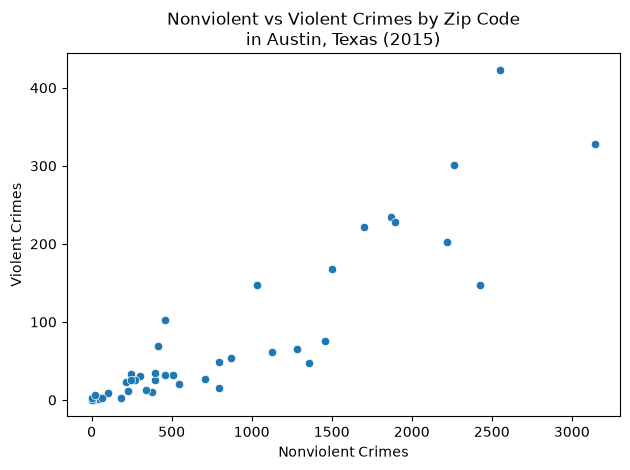

In [9]:
crime_by_zip = crime.groupby('Zip_Code_Crime')['violent_crime_string'].value_counts().unstack(fill_value=0)

ax = sns.scatterplot(x = 'False', y = 'True', data = crime_by_zip)

ax.set_title("Nonviolent vs Violent Crimes by Zip Code\nin Austin, Texas (2015)")
ax.set_xlabel("Nonviolent Crimes")
ax.set_ylabel("Violent Crimes")

plt.tight_layout()
plt.show()

In [10]:
stats.pearsonr(crime_by_zip['False'], crime_by_zip['True'])

PearsonRResult(statistic=np.float64(0.9038699419011683), pvalue=np.float64(3.3184793879239737e-18))

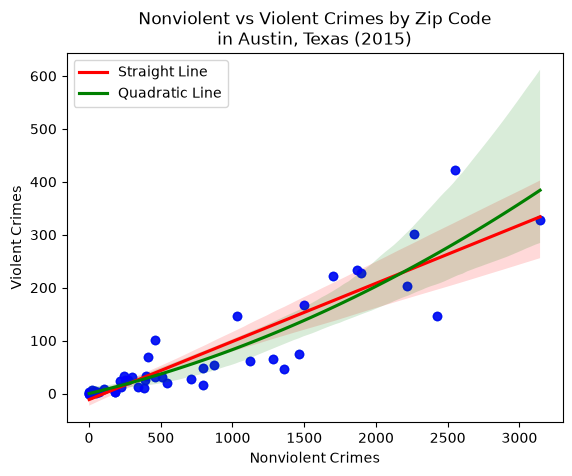

Straight Line RMSE: 42.2100
Quadratic Line RMSE: 40.4491


In [11]:
sns.regplot(x = 'False', y = 'True', data = crime_by_zip,
    order=1,
    line_kws={"color": "red", "label": "Straight Line"}
)

sns.regplot(x = 'False', y = 'True', data = crime_by_zip,
    order=2,
    scatter_kws={"color": "blue"},
    line_kws={"color": "green", "label": "Quadratic Line"},
)

plt.title("Nonviolent vs Violent Crimes by Zip Code\nin Austin, Texas (2015)")
plt.xlabel("Nonviolent Crimes")
plt.ylabel("Violent Crimes")
plt.legend()

plt.tight_layout
plt.show()

coef_lin = np.polyfit(crime_by_zip["False"], crime_by_zip["True"], 1)
pred_lin = np.polyval(coef_lin, crime_by_zip["False"])
rmse_lin = np.sqrt(mean_squared_error(crime_by_zip["True"], pred_lin))


coef_quad = np.polyfit(crime_by_zip["False"], crime_by_zip["True"], 2)
pred_quad = np.polyval(coef_quad, crime_by_zip["False"])
rmse_quad = np.sqrt(mean_squared_error(crime_by_zip["True"], pred_quad))

print(f"Straight Line RMSE: {rmse_lin:.4f}")
print(f"Quadratic Line RMSE: {rmse_quad:.4f}")


The quadratic line fits slightly better, and the line shows that zip codes with more crime tend to have a higher ratio of violent crime. This effect isn't very large, but it does have theoretical backing.

# Unemployment

In [12]:
population = pd.read_csv("AustinZipCodes.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'AustinZipCodes.csv'

In [ ]:
crime['unemployment_num'] = pd.to_numeric(crime.Unemployment.str.replace("%", "", regex=False))
sns.displot(crime.unemployment_num)

In [ ]:
crime_pop = crime.merge(population, left_on='Zip_Code_Crime', right_on='Zip Code')
crime_pop['Population'] = pd.to_numeric(crime_pop['Population'].str.replace(",", "", regex=False))
crime_num_zip = crime_pop.groupby('Zip_Code_Crime').size().to_frame().rename(columns={0: "num_crimes"})
crime_pop_zip = crime_pop.groupby('Zip_Code_Crime').agg({"unemployment_num": ["mean"], "Population": ["mean"]}).droplevel(level=1, axis=1)
crime_per_capita = crime_num_zip.merge(crime_pop_zip, on = 'Zip_Code_Crime')

crime_per_capita['unemployment_level'] = crime_per_capita['unemployment_num'].case_when(
    [
        (crime_per_capita['unemployment_num'] > 12, 'High'),
        (crime_per_capita['unemployment_num'] > 8, 'Medium High'),
        (crime_per_capita['unemployment_num'] > 4, 'Medium Low'),
        (crime_per_capita['unemployment_num'] >= 0, 'Low'),
    ]
)

In [ ]:
crime_per_capita = crime_per_capita.groupby('unemployment_level').agg(
    {"num_crimes": ["sum"], "Population": ["sum"]}
    ).reset_index().droplevel(level=1, axis=1)
crime_per_capita['crimes_per_capita'] = crime_per_capita.num_crimes / crime_per_capita.Population

plt.figure(figsize=(9.5, 7))
ax = sns.barplot(data = crime_per_capita, x = 'unemployment_level', y = 'crimes_per_capita',
            order = ['Low', 'Medium Low', 'Medium High', 'High'])

ax.set_xticklabels(['Low (0-4%)', 'Moderately Low (5-8%)', 'Moderately High (9-12%)', 'High (13-16%)'])

plt.title("Crimes per Capita by Unemployment Level in Austin, Texas (2015)")
plt.xlabel("Unemployment Level")
plt.ylabel("Crimes per Capita")

plt.show()

# Poverty

In [12]:
def clean_numeric(series):
    """
    Remove $, %, and commas and convert values to numeric.
    Invalid/missing values become NaN.
    """
    return pd.to_numeric(
        series.astype("string")
            .str.replace("$", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.strip(),
        errors="coerce"
    )

numeric_housing_columns = [
    "Populationbelowpovertylevel",
    "Medianhouseholdincome",
    "Medianrent",
    "Medianhomevalue",
    "Homesaffordabletopeopleearninglessthan$50000",
    "Rentalsaffordabletopeopleearninglessthan$25000",
    "Ownerunitsaffordabletoaverageretail/serviceworker",
    "Rentalunitsaffordabletoaverageretail/serviceworker",
]

# Re-reading data for fresh analysis and cleaning
crime = pd.read_csv("crime-housing-austin-2015.csv")

for column in numeric_housing_columns:
    crime[column] = clean_numeric(crime[column])

crime[numeric_housing_columns].head()

,Populationbelowpovertylevel,Medianhouseholdincome,Medianrent,Medianhomevalue,Homesaffordabletopeopleearninglessthan$50000,Rentalsaffordabletopeopleearninglessthan$25000,Ownerunitsaffordabletoaverageretail/serviceworker,Rentalunitsaffordabletoaverageretail/serviceworker
0,26,39593,826,134900,78,14,8,11
1,26,38624,865,292200,11,13,0,9
2,26,39593,826,134900,78,14,8,11
3,26,39593,826,134900,78,14,8,11
4,26,41056,946,108100,93,7,13,6


In [13]:
crime_counts = (
    crime.dropna(subset=["Zip_Code_Housing"])
         .groupby("Zip_Code_Housing")
         .size()
         .rename("Crime_Count")
)

crime_counts.head()

Zip_Code_Housing
78617.0     276
78701.0    2103
78702.0    1668
78703.0     738
78704.0    2571
Name: Crime_Count, dtype: int64

In [14]:
housing_columns = [
    "Populationbelowpovertylevel",
    "Medianhouseholdincome",
    "Medianrent",
    "Medianhomevalue",
    "Homesaffordabletopeopleearninglessthan$50000",
    "Rentalsaffordabletopeopleearninglessthan$25000",
    "Ownerunitsaffordabletoaverageretail/serviceworker",
    "Rentalunitsaffordabletoaverageretail/serviceworker",
]

housing_data = (
    crime.dropna(subset=["Zip_Code_Housing"])
         .groupby("Zip_Code_Housing")[housing_columns]
         .first()
)

housing_data.head()

,Populationbelowpovertylevel,Medianhouseholdincome,Medianrent,Medianhomevalue,Homesaffordabletopeopleearninglessthan$50000,Rentalsaffordabletopeopleearninglessthan$25000,Ownerunitsaffordabletoaverageretail/serviceworker,Rentalunitsaffordabletoaverageretail/serviceworker
Zip_Code_Housing,,,,,,,,
78617.0,18,43957,1041,100600,<NA>,11,<NA>,7
78701.0,20,68152,1590,338300,7,7,0,7
78702.0,33,34734,766,175400,21,41,0,39
78703.0,10,92606,1183,621900,3,11,0,8
78704.0,21,50248,940,338200,13,12,0,11


In [15]:
analysis_df = housing_data.join(crime_counts, how="inner")

print("Number of ZIP codes:", len(analysis_df))
analysis_df.head()

Number of ZIP codes: 36


,Populationbelowpovertylevel,Medianhouseholdincome,Medianrent,Medianhomevalue,Homesaffordabletopeopleearninglessthan$50000,Rentalsaffordabletopeopleearninglessthan$25000,Ownerunitsaffordabletoaverageretail/serviceworker,Rentalunitsaffordabletoaverageretail/serviceworker,Crime_Count
Zip_Code_Housing,,,,,,,,,
78617.0,18,43957,1041,100600,<NA>,11,<NA>,7,276
78701.0,20,68152,1590,338300,7,7,0,7,2103
78702.0,33,34734,766,175400,21,41,0,39,1668
78703.0,10,92606,1183,621900,3,11,0,8,738
78704.0,21,50248,940,338200,13,12,0,11,2571


In [16]:
analysis_df["Rent_to_Income_Pct"] = (
    analysis_df["Medianrent"] * 12
    / analysis_df["Medianhouseholdincome"]
    * 100
)

analysis_df[
    ["Medianrent", "Medianhouseholdincome", "Rent_to_Income_Pct"]
].head()

,Medianrent,Medianhouseholdincome,Rent_to_Income_Pct
Zip_Code_Housing,,,
78617.0,1041,43957,28.418682
78701.0,1590,68152,27.996244
78702.0,766,34734,26.463983
78703.0,1183,92606,15.32946
78704.0,940,50248,22.448655


In [17]:
analysis_df["Avg_Worker_Affordability_Pct"] = (
    analysis_df[
        [
            "Ownerunitsaffordabletoaverageretail/serviceworker",
            "Rentalunitsaffordabletoaverageretail/serviceworker"
        ]
    ].mean(axis=1)
)

analysis_df[
    [
        "Ownerunitsaffordabletoaverageretail/serviceworker",
        "Rentalunitsaffordabletoaverageretail/serviceworker",
        "Avg_Worker_Affordability_Pct"
    ]
].head()

,Ownerunitsaffordabletoaverageretail/serviceworker,Rentalunitsaffordabletoaverageretail/serviceworker,Avg_Worker_Affordability_Pct
Zip_Code_Housing,,,
78617.0,<NA>,7,7.0
78701.0,0,7,3.5
78702.0,0,39,19.5
78703.0,0,8,4.0
78704.0,0,11,5.5


In [18]:
analysis_df[
    [
        "Crime_Count",
        "Populationbelowpovertylevel",
        "Medianhouseholdincome",
        "Medianrent",
        "Rent_to_Income_Pct",
        "Avg_Worker_Affordability_Pct"
    ]
].describe()

,Crime_Count,Populationbelowpovertylevel,Medianhouseholdincome,Medianrent,Rent_to_Income_Pct,Avg_Worker_Affordability_Pct
count,36.000000,36.0,36.0,36.0,36.0,36.0
mean,1035.694444,18.083333,61180.777778,1030.25,24.216097,6.333333
std,937.321741,13.910684,29183.570532,260.522812,15.700819,7.922842
min,1.000000,1.0,11917.0,639.0,11.099496,0.0
25%,323.500000,7.75,40690.25,893.25,17.784866,1.0
50%,652.000000,15.0,54215.0,979.5,22.137718,3.5
75%,1569.000000,26.0,74917.75,1089.75,26.566608,9.5
max,3472.000000,66.0,127726.0,2000.0,109.557775,36.5


In [19]:
variables = [
    "Crime_Count",
    "Populationbelowpovertylevel",
    "Rent_to_Income_Pct",
    "Medianhouseholdincome"
]

std_results = analysis_df[variables].std()

print("Standard Deviations:")
print(std_results)

Standard Deviations:
Crime_Count                      937.321741
Populationbelowpovertylevel       13.910684
Rent_to_Income_Pct                15.700819
Medianhouseholdincome          29183.570532
dtype: Float64


In [20]:
poverty_data = analysis_df[
    ["Populationbelowpovertylevel", "Crime_Count"]
].dropna()

r_poverty, p_poverty = stats.pearsonr(
    poverty_data["Populationbelowpovertylevel"],
    poverty_data["Crime_Count"]
)

print("Poverty vs. Crime")
print("-----------------")
print(f"Pearson r = {r_poverty:.3f}")
print(f"p-value   = {p_poverty:.4f}")
print(f"n         = {len(poverty_data)}")

Poverty vs. Crime
-----------------
Pearson r = 0.411
p-value   = 0.0127
n         = 36


In [21]:
poverty_median = analysis_df["Populationbelowpovertylevel"].median()

analysis_df["Poverty_Group"] = np.where(
    analysis_df["Populationbelowpovertylevel"] >= poverty_median,
    "High Poverty",
    "Low Poverty"
)

print("Median poverty percentage:", poverty_median)

analysis_df[
    ["Populationbelowpovertylevel", "Crime_Count", "Poverty_Group"]
].head(10)

Median poverty percentage: 15.0


,Populationbelowpovertylevel,Crime_Count,Poverty_Group
Zip_Code_Housing,,,
78617.0,18,276,High Poverty
78701.0,20,2103,High Poverty
78702.0,33,1668,High Poverty
78703.0,10,738,Low Poverty
78704.0,21,2571,High Poverty
78705.0,66,1346,High Poverty
78717.0,3,237,Low Poverty
78721.0,32,482,High Poverty
78722.0,19,332,High Poverty


In [22]:
high_poverty_crime = analysis_df.loc[
    analysis_df["Poverty_Group"] == "High Poverty",
    "Crime_Count"
].dropna()

low_poverty_crime = analysis_df.loc[
    analysis_df["Poverty_Group"] == "Low Poverty",
    "Crime_Count"
].dropna()

t_poverty, p_t_poverty = stats.ttest_ind(
    high_poverty_crime,
    low_poverty_crime,
    equal_var=False
)

print("Poverty Group T-Test")
print("--------------------")
print(f"High-poverty mean crime count: {high_poverty_crime.mean():.2f}")
print(f"Low-poverty mean crime count:  {low_poverty_crime.mean():.2f}")
print(f"t-statistic: {t_poverty:.3f}")
print(f"p-value:     {p_t_poverty:.4f}")

Poverty Group T-Test
--------------------
High-poverty mean crime count: 1563.11
Low-poverty mean crime count:  508.28
t-statistic: 4.052
p-value:     0.0005


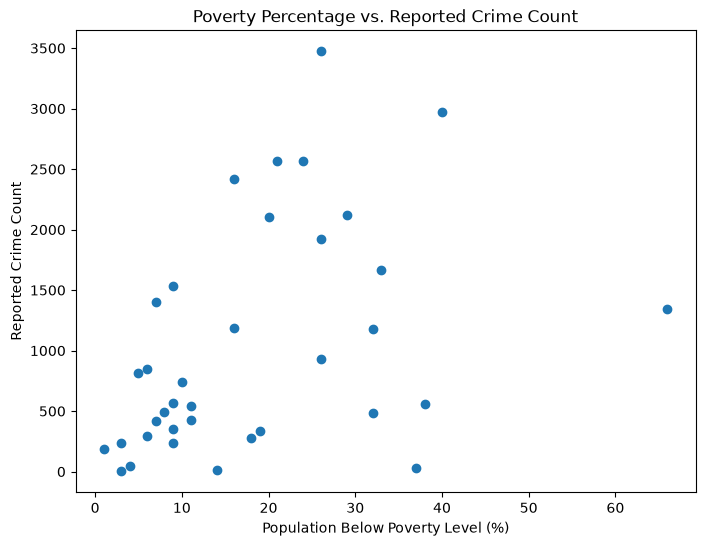

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis_df["Populationbelowpovertylevel"],
    analysis_df["Crime_Count"]
)

plt.xlabel("Population Below Poverty Level (%)")
plt.ylabel("Reported Crime Count")
plt.title("Poverty Percentage vs. Reported Crime Count")

plt.show()

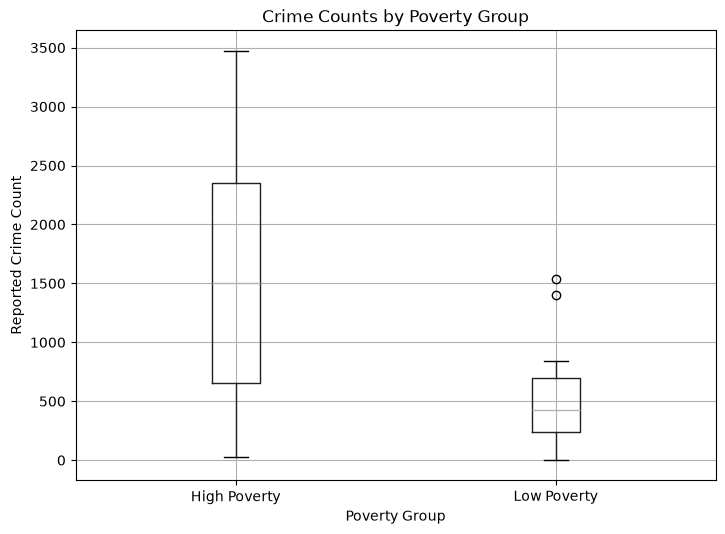

In [24]:
analysis_df.boxplot(
    column="Crime_Count",
    by="Poverty_Group",
    figsize=(8, 6)
)

plt.title("Crime Counts by Poverty Group")
plt.suptitle("")
plt.xlabel("Poverty Group")
plt.ylabel("Reported Crime Count")

plt.show()

# Housing Affordability

In [25]:
affordability_data = analysis_df[
    ["Rent_to_Income_Pct", "Crime_Count"]
].dropna()

r_affordability, p_affordability = stats.pearsonr(
    affordability_data["Rent_to_Income_Pct"],
    affordability_data["Crime_Count"]
)

print("Rent-to-Income vs. Crime")
print("------------------------")
print(f"Pearson r = {r_affordability:.3f}")
print(f"p-value   = {p_affordability:.4f}")
print(f"n         = {len(affordability_data)}")

Rent-to-Income vs. Crime
------------------------
Pearson r = 0.211
p-value   = 0.2172
n         = 36


In [26]:
affordability_median = analysis_df["Rent_to_Income_Pct"].median()

analysis_df["Affordability_Group"] = np.where(
    analysis_df["Rent_to_Income_Pct"] >= affordability_median,
    "Less Affordable",
    "More Affordable"
)

print("Median rent-to-income percentage:",
      affordability_median)

Median rent-to-income percentage: 22.137718484063164


In [27]:
less_affordable_crime = analysis_df.loc[
    analysis_df["Affordability_Group"] == "Less Affordable",
    "Crime_Count"
].dropna()

more_affordable_crime = analysis_df.loc[
    analysis_df["Affordability_Group"] == "More Affordable",
    "Crime_Count"
].dropna()

t_affordability, p_t_affordability = stats.ttest_ind(
    less_affordable_crime,
    more_affordable_crime,
    equal_var=False
)

print("Housing Affordability T-Test")
print("----------------------------")
print(f"Less-affordable mean crime count: "
      f"{less_affordable_crime.mean():.2f}")

print(f"More-affordable mean crime count: "
      f"{more_affordable_crime.mean():.2f}")

print(f"t-statistic: {t_affordability:.3f}")
print(f"p-value:     {p_t_affordability:.4f}")

Housing Affordability T-Test
----------------------------
Less-affordable mean crime count: 1497.94
More-affordable mean crime count: 573.44
t-statistic: 3.368
p-value:     0.0027


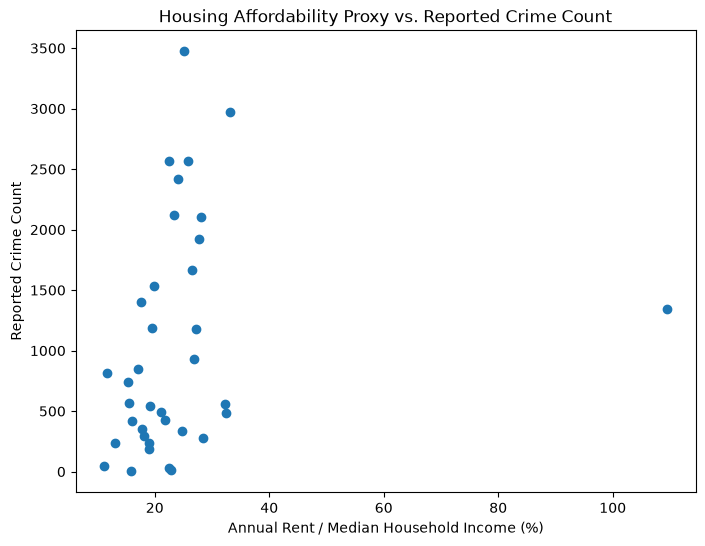

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis_df["Rent_to_Income_Pct"],
    analysis_df["Crime_Count"]
)

plt.xlabel("Annual Rent / Median Household Income (%)")
plt.ylabel("Reported Crime Count")
plt.title("Housing Affordability Proxy vs. Reported Crime Count")

plt.show()

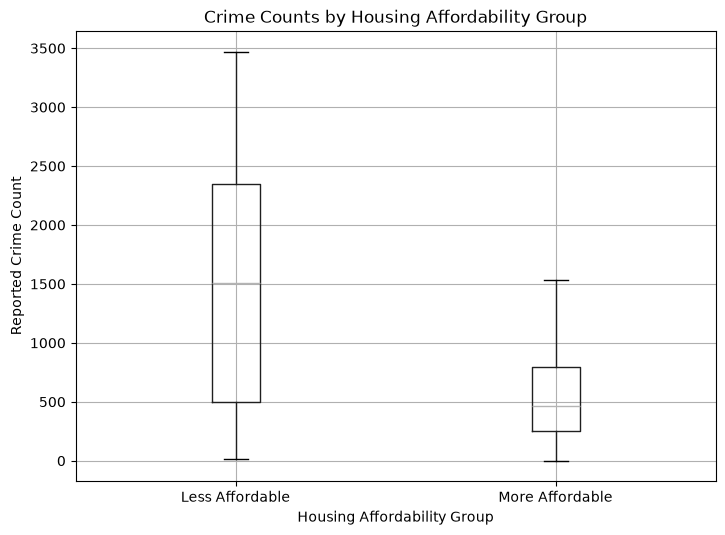

In [29]:
analysis_df.boxplot(
    column="Crime_Count",
    by="Affordability_Group",
    figsize=(8, 6)
)

plt.title("Crime Counts by Housing Affordability Group")
plt.suptitle("")
plt.xlabel("Housing Affordability Group")
plt.ylabel("Reported Crime Count")

plt.show()

In [30]:
results = pd.DataFrame({
    "Analysis": [
        "Poverty vs. Crime",
        "Housing Affordability vs. Crime"
    ],
    "Pearson_r": [
        r_poverty,
        r_affordability
    ],
    "Pearson_p": [
        p_poverty,
        p_affordability
    ],
    "T_statistic": [
        t_poverty,
        t_affordability
    ],
    "T_test_p": [
        p_t_poverty,
        p_t_affordability
    ]
})

results

,Analysis,Pearson_r,Pearson_p,T_statistic,T_test_p
0,Poverty vs. Crime,0.411416,0.012671,4.052122,0.000496
1,Housing Affordability vs. Crime,0.210775,0.217227,3.367902,0.002710
